<a href="https://colab.research.google.com/github/LOKESH1027-V/fashion-mnist-classifier/blob/main/pytorch_cnn_model0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
from torch import nn

#importing tochvision main lib for computer vison program

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

In [3]:
print(torch.__version__)
print(torchvision.__version__)

2.12.0+cu130
0.27.0+cu130


In [4]:
#downloading the dataset
from torchvision import datasets

train=datasets.FashionMNIST(root="data",train=True,download=True,transform=ToTensor(),target_transform=None)#target transform means label
test=datasets.FashionMNIST(root="data",train=False,download=True,transform=ToTensor(),target_transform=None)

100.0%
100.0%
100.0%
100.0%


In [5]:
train

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
train[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [7]:
train

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [8]:
image,label=train[0]

In [9]:
label

9

In [10]:
class_name=train.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [11]:
classed_to_idex=train.class_to_idx
classed_to_idex

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [12]:
image.shape

torch.Size([1, 28, 28])

In [13]:
print(f'Image shape : {image.shape} -->[color channels,height,width]' )
print(f'Image label : {class_name[label]}')

Image shape : torch.Size([1, 28, 28]) -->[color channels,height,width]
Image label : Ankle boot


Image  shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, 'Ankle boot')

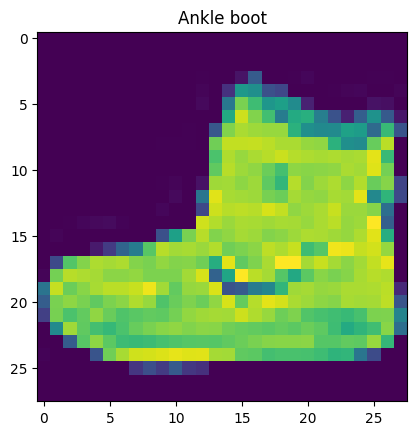

In [14]:
#visualizing the image
import matplotlib.pyplot as plt

image,label=train[0]
print(f'Image  shape: {image.shape}')
plt.imshow(image.squeeze())
plt.title(class_name[label])

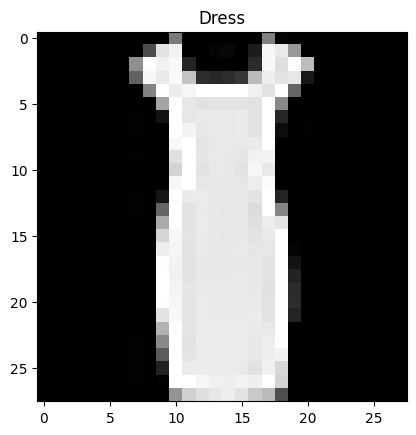

In [15]:
n=torch.randint(0,len(train),(1,)).item()
image,label=train[n]
plt.title(class_name[label])
plt.imshow(image.squeeze(),cmap="gray")

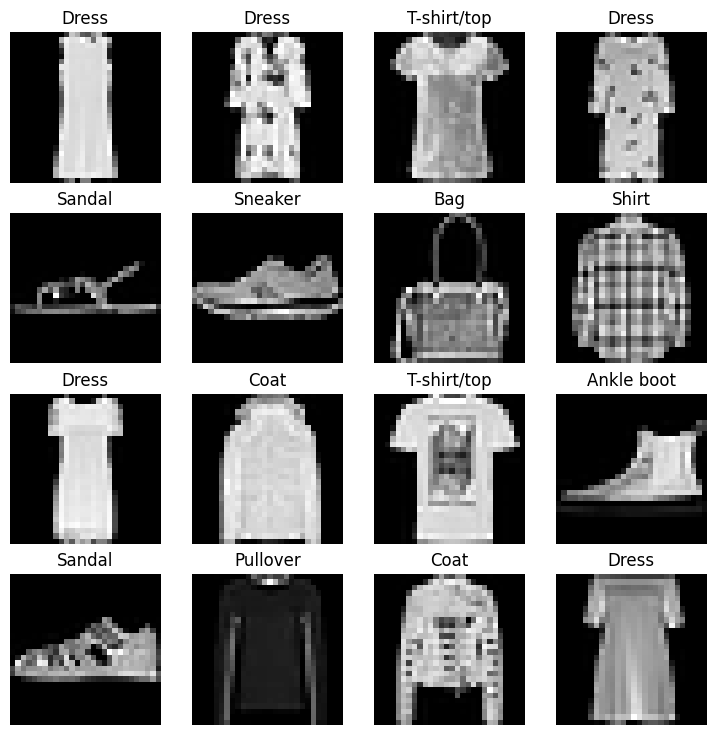

In [16]:
plt.figure(figsize=(9,9))
rows,columns=4,4
for i in range(1,rows*columns+1):
  rand_idx=torch.randint(0,len(train),size=[1]).item()
  img ,label=train[rand_idx]
  plt.subplot(rows,columns,i)
  plt.imshow(img.squeeze(),cmap="gray")
  plt.axis(False)
  plt.title(class_name[label])

In [17]:
train

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [18]:
#Prepare dataloader
#Turn our data into mini batches
from torch.utils.data import DataLoader

b_size=32

train_dataloader=DataLoader(dataset=train,
                            batch_size=b_size,
                            shuffle=True)
test_dataloader=DataLoader(dataset=test,
                           batch_size=b_size,
                           shuffle=False)

In [19]:
print(f"DataLoader :{train_dataloader} {test_dataloader}")
print(f"Batch size of the trian data {len(train_dataloader)} of batch size {b_size}")
print(f"Batch size of the test data {len(test_dataloader)} of batch size {b_size}")


DataLoader :<torch.utils.data.dataloader.DataLoader object at 0x7fd16430b9a0> <torch.utils.data.dataloader.DataLoader object at 0x7fd164308790>
Batch size of the trian data 1875 of batch size 32
Batch size of the test data 313 of batch size 32


In [20]:
train_featuure,train_label=next(iter(train_dataloader))
train_label

tensor([7, 8, 0, 7, 8, 3, 0, 6, 7, 0, 4, 3, 7, 7, 7, 9, 0, 5, 0, 0, 4, 8, 8, 8,
        4, 3, 3, 6, 4, 3, 9, 5])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

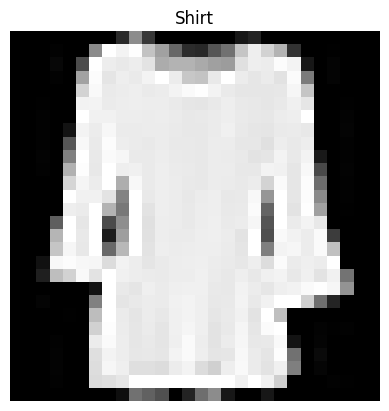

In [21]:
rand_idx=torch.randint(0,len(train_featuure),size=[1]).item()
img, label=train_featuure[rand_idx],train_label[rand_idx]
plt.title(class_name[label])
plt.imshow(img.squeeze(),cmap="gray")
plt.axis(False)

In [22]:
flatten=nn.Flatten()
x=flatten(train_featuure[0])
train_featuure.shape

torch.Size([32, 1, 28, 28])

In [23]:
x.shape

torch.Size([1, 784])

In [24]:
from torch import nn
class FashionMINSTModel1(nn.Module):
  def __init__(self,input_shape:int,
               hidden_unit:int,
               output_shape:int):
    super().__init__()
    self.layer=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_unit),
        nn.Linear(in_features=hidden_unit,out_features=output_shape)

        )
  def forward(self,x):
      return self.layer(x)

In [25]:
length=len(class_name)

In [26]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [27]:
Model_0=FashionMINSTModel1(input_shape=784,hidden_unit=10,output_shape=length).to(device)

In [28]:
Model_0

FashionMINSTModel1(
  (layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [29]:
Model_0.state_dict()

OrderedDict([('layer.1.weight',
              tensor([[-0.0118,  0.0064,  0.0131,  ..., -0.0287,  0.0052,  0.0357],
                      [ 0.0074,  0.0169,  0.0302,  ..., -0.0227, -0.0038, -0.0220],
                      [-0.0304,  0.0275,  0.0022,  ..., -0.0238,  0.0024,  0.0201],
                      ...,
                      [ 0.0097,  0.0097, -0.0022,  ...,  0.0119, -0.0305,  0.0290],
                      [-0.0356,  0.0242, -0.0004,  ...,  0.0153,  0.0205, -0.0003],
                      [ 0.0257, -0.0057,  0.0169,  ..., -0.0345,  0.0186, -0.0246]])),
             ('layer.1.bias',
              tensor([-0.0286, -0.0333, -0.0154, -0.0299,  0.0240, -0.0079, -0.0218,  0.0022,
                      -0.0319,  0.0111])),
             ('layer.2.weight',
              tensor([[-0.2018,  0.2299, -0.2877,  0.0080, -0.0837,  0.1455,  0.2547,  0.0244,
                        0.0776,  0.1626],
                      [ 0.1023, -0.1880,  0.1217,  0.0318,  0.1344,  0.1752,  0.1600,  0.0455,
   

In [30]:
x=torch.rand([1,1,28,28])
x.shape

torch.Size([1, 1, 28, 28])

lossfunction and optimizer

In [31]:
loss_fn=nn.CrossEntropyLoss()

optimizer=torch.optim.SGD(params=Model_0.parameters(),lr=0.01)


In [32]:
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [33]:
from timeit import default_timer as timer
def timeing(start:float,
          end:float,
          device=None):
  total=end-start
  print(f'The total time take by {device} is {total}')

In [36]:
#imorting the progress bar
from tqdm.auto import tqdm
torch.manual_seed(2)
train_time_start=timer()
epoches=3
for epoche in tqdm(range(epoches)):

  train_loss=0
  for batch,(X,y) in enumerate(train_dataloader):
    X=X.to(device)
    y=y.to(device)
    Model_0.train()
    y_pred=Model_0(X)
    loss=loss_fn(y_pred,y)
    train_loss+=loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch%400==0:
      print(f'Looking at the batch {batch*len(X)}/{len(train_dataloader.dataset)} samples')
  train_loss/=len(train_dataloader)
  test_loss=0
  test_acc=0
  with torch.inference_mode():
    for x_test,y_test in test_dataloader:
      x_test=x_test.to(device)
      y_test=y_test.to(device)
      test_pred=Model_0(x_test)
      test_loss+=loss_fn(test_pred,y_test).item()
      test_acc+=accuracy_fn(y_true=y_test,y_pred=test_pred.argmax(dim=1))
    test_loss/=len(test_dataloader)
    test_acc/=len(test_dataloader)


  print(f"\nTraining loss : {train_loss:.5f} | test loss : {test_loss:.5f} | test acc : {test_acc:.5f}")
#calculating the timer
end_time=timer()
timeing(train_time_start,end_time)


  0%|          | 0/3 [00:00<?, ?it/s]

Looking at the batch 0/60000 samples
Looking at the batch 12800/60000 samples
Looking at the batch 25600/60000 samples
Looking at the batch 38400/60000 samples
Looking at the batch 51200/60000 samples

Training loss : 0.93467 | test loss : 0.64982 | test acc : 77.03674
Looking at the batch 0/60000 samples
Looking at the batch 12800/60000 samples
Looking at the batch 25600/60000 samples
Looking at the batch 38400/60000 samples
Looking at the batch 51200/60000 samples

Training loss : 0.56998 | test loss : 0.54656 | test acc : 81.07029
Looking at the batch 0/60000 samples
Looking at the batch 12800/60000 samples
Looking at the batch 25600/60000 samples
Looking at the batch 38400/60000 samples
Looking at the batch 51200/60000 samples

Training loss : 0.50774 | test loss : 0.51595 | test acc : 81.98882
The total time take by None is 23.221205636999912


In [37]:
str(next(Model_0.parameters()).device)

'cpu'

In [38]:
torch.manual_seed(2)

def model_eval(model:torch.nn.Module,
               data_loader:  torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  loss=0
  acc=0
  model.eval()
  with torch.inference_mode():
    for x,y in data_loader:
      x=x.to(device)
      y=y.to(device)
      y_pred=model(x)

      loss+=loss_fn(y_pred,y).item()

      acc+=accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))

    loss/=len(data_loader)
    acc/=len(data_loader)
  return {
      "model_name": model.__class__.__name__,
      "model_loss": loss,
      "model_acc": acc
  }

model0=model_eval(Model_0,test_dataloader,loss_fn,accuracy_fn)
model0

{'model_name': 'FashionMINSTModel1',
 'model_loss': 0.5159499418621246,
 'model_acc': 81.9888178913738}

Create a model with non linearity

In [39]:
class FashionMINSTModelV1(nn.Module):
  def __init__(self,input:int,hidden:int,output:int):
    super().__init__()
    self.layers=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input,out_features=hidden),
        nn.ReLU(),
        nn.Linear(in_features=hidden,out_features=output),
        nn.ReLU()
    )
  def forward(self,x):
      return self.layers(x)

In [41]:
modelV1=FashionMINSTModelV1(input=784,hidden=10,output=len(class_name)).to(device)

In [42]:
str(next(modelV1.parameters()).device)

'cpu'

In [43]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [44]:
#loss function and optimer
loss_fn=nn.CrossEntropyLoss()

optimizer=torch.optim.SGD(params=modelV1.parameters(),lr=0.01)

In [45]:
def train_step(data_loader: torch.utils.data.DataLoader,
               model: nn.Module,
               loss_fn: nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):

    train_loss = 0

    model.train()

    for batch, (x, y) in enumerate(data_loader):

        x = x.to(device)
        y = y.to(device)

        y_pred = model(x)

        loss = loss_fn(y_pred, y)

        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if batch % 400 == 0:
            print(
                f"Looking at batch "
                f"{batch * len(x)}/{len(data_loader.dataset)} samples"
            )

    train_loss /= len(data_loader)

    return train_loss

In [46]:
def test_step(data_loader:torch.utils.data.DataLoader,model:nn.Module,
               loss_fn:nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device=device):
  test_loss=0
  acc=0
  model.eval()
  with torch.inference_mode():
    for x,y in data_loader:
      x=x.to(device)
      y=y.to(device)
      y_pred=model(x)
      loss=loss_fn(y_pred,y)
      test_loss+=loss.item()
      acc+=accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
    loss/=len(data_loader)
    acc/=len(data_loader)

  return test_loss,acc


In [47]:
device = "cuda" if torch.cuda.is_available() else "cpu"
def train_test_loop(train_data_loader:torch.utils.data.DataLoader,
                    test_data_loader:torch.utils.data.DataLoader,model:nn.Module,
               loss_fn:nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device=device):
  train_loss=train_step(train_data_loader,model,loss_fn,optimizer,accuracy_fn,device)
  test_loss,test_acc=test_step(train_data_loader,model,loss_fn,optimizer,accuracy_fn,device)
  print(f"Train loss : {train_loss:.5f} | test loss : {test_loss:.4f} | test acc : {test_acc:.3f}")



In [48]:
train_test_loop(train_dataloader,test_dataloader,modelV1,loss_fn,optimizer,accuracy_fn,device)

Looking at batch 0/60000 samples
Looking at batch 12800/60000 samples
Looking at batch 25600/60000 samples
Looking at batch 38400/60000 samples
Looking at batch 51200/60000 samples
Train loss : 1.42138 | test loss : 2059.0892 | test acc : 62.855


In [49]:
epochs=3
for epoch in range(epochs):
  train_test_loop(train_dataloader,test_dataloader,modelV1,loss_fn,optimizer,accuracy_fn,device)



Looking at batch 0/60000 samples
Looking at batch 12800/60000 samples
Looking at batch 25600/60000 samples
Looking at batch 38400/60000 samples
Looking at batch 51200/60000 samples
Train loss : 0.93224 | test loss : 1506.9830 | test acc : 75.243
Looking at batch 0/60000 samples
Looking at batch 12800/60000 samples
Looking at batch 25600/60000 samples
Looking at batch 38400/60000 samples
Looking at batch 51200/60000 samples
Train loss : 0.76374 | test loss : 1362.4364 | test acc : 78.577
Looking at batch 0/60000 samples
Looking at batch 12800/60000 samples
Looking at batch 25600/60000 samples
Looking at batch 38400/60000 samples
Looking at batch 51200/60000 samples
Train loss : 0.71236 | test loss : 1300.3996 | test acc : 79.842


Building model2
Convolutional neural network

In [50]:
class FashionMNISTModelV3(nn.Module):
  def __init__(self,input:int,hidden:int,out:int):
    super().__init__()
    self.convblock1=nn.Sequential(
        nn.Conv2d(in_channels=input,out_channels=hidden,
                  kernel_size=(2,2),
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden,out_channels=hidden,
          kernel_size=(2,2),
          padding=1,
          stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2))
    )
    self.convblock2=nn.Sequential(
        nn.Conv2d(in_channels=hidden,out_channels=hidden,
                  kernel_size=(2,2),
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden,out_channels=hidden,
                  kernel_size=(2,2),
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2))

    )
    self.Linear_layer=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden*8*8,out_features=out)
    )
  def forward(self,x):
    x=self.convblock1(x)
    x=self.convblock2(x)
    x=self.Linear_layer(x)
    return x

In [51]:
image.shape

torch.Size([1, 28, 28])

In [52]:
torch.manual_seed(2)
model3=FashionMNISTModelV3(input=1,hidden=10,out=len(class_name)).to(device)

In [53]:
image.shape
image=image.to(device)
image.shape

torch.Size([1, 28, 28])

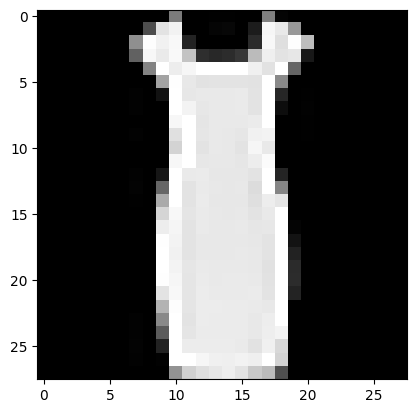

In [54]:
plt.imshow(image.squeeze(),cmap='gray')

In [55]:
rand_img_tensor=torch.randn(size=(1,28,28))
rand_img_tensor.shape

torch.Size([1, 28, 28])

In [56]:
model3(rand_img_tensor.unsqueeze(0))

tensor([[ 0.0128,  0.0324, -0.0751,  0.0239, -0.0417,  0.0463, -0.0451, -0.0391,
         -0.0080,  0.0638]], grad_fn=<AddmmBackward0>)

In [57]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model3.parameters(),lr=0.01)


In [58]:
from timeit import default_timer as Timer
start_time=timer()

epochs=10
for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch}--------------")
  train_test_loop(train_dataloader,test_dataloader,model3,loss_fn,optimizer,accuracy_fn,device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch : 0--------------
Looking at batch 0/60000 samples
Looking at batch 12800/60000 samples
Looking at batch 25600/60000 samples
Looking at batch 38400/60000 samples
Looking at batch 51200/60000 samples
Train loss : 1.56176 | test loss : 1320.7117 | test acc : 72.333
Epoch : 1--------------
Looking at batch 0/60000 samples
Looking at batch 12800/60000 samples
Looking at batch 25600/60000 samples
Looking at batch 38400/60000 samples
Looking at batch 51200/60000 samples
Train loss : 0.61662 | test loss : 1147.6105 | test acc : 78.353
Epoch : 2--------------
Looking at batch 0/60000 samples
Looking at batch 12800/60000 samples
Looking at batch 25600/60000 samples
Looking at batch 38400/60000 samples
Looking at batch 51200/60000 samples
Train loss : 0.53403 | test loss : 1038.5340 | test acc : 80.413
Epoch : 3--------------
Looking at batch 0/60000 samples
Looking at batch 12800/60000 samples
Looking at batch 25600/60000 samples
Looking at batch 38400/60000 samples
Looking at batch 51200

In [60]:
model3.state_dict()

OrderedDict([('convblock1.0.weight',
              tensor([[[[ 0.0876, -0.1201],
                        [ 0.1091, -0.0282]]],
              
              
                      [[[ 0.2136,  0.1190],
                        [-0.0575, -0.4042]]],
              
              
                      [[[ 0.0606, -0.9382],
                        [ 0.2681, -0.1988]]],
              
              
                      [[[-0.1178,  1.0606],
                        [ 0.2062,  0.7538]]],
              
              
                      [[[ 0.2258, -0.3271],
                        [-0.1553,  0.5509]]],
              
              
                      [[[-0.9779, -0.0115],
                        [-0.3783,  0.3649]]],
              
              
                      [[[-0.1249,  0.0331],
                        [-0.1171, -0.5531]]],
              
              
                      [[[-0.2834, -0.2429],
                        [-0.4542, -0.3245]]],
              
              
   

In [61]:
torch.save(model3.state_dict(), "fashionmnist_cnn.pth")